# Cluster analysis and validation

This notebook explores the semantic structure of Last.fm genre tags using TF-IDF, UMAP and K-Means clustering. Initial clusters are iteratively reviewed and consolidated into four interpretable macro-clusters used in the final longitudinal analysis.


## 1. Load libraries

In [2]:
# env: music-umap as umap needed numpy < 2
import pandas as pd
import umap
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
import ast

/usr/local/anaconda3/envs/music-umap/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Load clustered dataset

In [3]:
model_df = pd.read_csv('../data/processed/lastfm_music_clusters_final.csv')

## 3. Dataset overview

In [ ]:
# Analyzed df contains ranking of unique tracks by play count, with associated tags and cluster assignments
# It doesn't contain the whole list of scrobbles or the full tag history, but it has enough data to visualize the clusters and understand their characteristics.
# All scrobbles will be in raw data
model_df.head()

,artist,track,timestamp,year_file,artist_clean,track_clean,parentheses,tags,tags_clean,tags_normalized,tags_filtered,tags_str,cluster,cluster_name,mood_cluster,cluster_name_v2,cluster_name_v3,macro_cluster,macro_cluster_v2,era
0,Oasis,Don't Look Back in Anger,1199052426,2007,oasis,dont look back in anger,[],['britpop' 'rock' 'british' 'alternative' 'ind...,['indie' 'rock' 'british' '90s' 'alternative r...,"['indie', 'rock', 'british', '90s', 'alternati...","[indie, alternative, britpop]",indie alternative britpop,1,classic rock / blues / psychedelic,energetic,British alternative rock,Rock Canon & Alternative Classics,Rock,Rock & Britrock,2008-2011
1,Oasis,Wonderwall,1199052167,2007,oasis,wonderwall,[],['britpop' 'rock' 'british' 'alternative' 'ind...,['indie' 'rock' 'british' '90s' 'alternative r...,"['indie', 'rock', 'british', '90s', 'alternati...","[indie, alternative, britpop]",indie alternative britpop,1,classic rock / blues / psychedelic,energetic,British alternative rock,Rock Canon & Alternative Classics,Rock,Rock & Britrock,2008-2011
2,Incubus,Aqueous Transmission,1199051161,2007,incubus,aqueous transmission,[],['alternative rock' 'rock' 'alternative' 'indi...,['american' 'indie' 'rock' 'alternative rock' ...,"['american', 'indie', 'rock', 'funk metal', 'a...","[indie, funk metal, alternative, groovy, jecks...",indie funk_metal alternative groovy jecks funk,3,art pop / neo soul / jazz,smooth,Alternative rock mainstream,Dark Alternative & Post-Punk,Dark Alternative,Alternative Core,2008-2011
3,Incubus,Under My Umbrella12DSGMS192,1199050947,2007,incubus,under my umbrella,[],['alternative rock' 'rock' 'alternative' 'indi...,['american' 'indie' 'rock' 'alternative rock' ...,"['american', 'indie', 'rock', 'funk metal', 'a...","[indie, funk metal, alternative, groovy, jecks...",indie funk_metal alternative groovy jecks funk,3,art pop / neo soul / jazz,smooth,Alternative rock mainstream,Dark Alternative & Post-Punk,Dark Alternative,Alternative Core,2008-2011
4,Incubus,Are You In11DSGMS192,1199050681,2007,incubus,are you in,[],['alternative rock' 'rock' 'alternative' 'indi...,['american' 'indie' 'rock' 'alternative rock' ...,"['american', 'indie', 'rock', 'funk metal', 'a...","[indie, funk metal, alternative, groovy, jecks...",indie funk_metal alternative groovy jecks funk,3,art pop / neo soul / jazz,smooth,Alternative rock mainstream,Dark Alternative & Post-Punk,Dark Alternative,Alternative Core,2008-2011


In [161]:
model_df.shape

(72823, 20)

In [14]:
top_50_all_time = model_df["artist_clean"].value_counts().head(50)

In [32]:
top_50_all_time

artist_clean
the cure                   215
depeche mode               213
red hot chili peppers      207
david bowie                205
radiohead                  197
the national               181
u2                         176
foo fighters               166
green day                  166
placebo                    165
pj harvey                  160
nick cave the bad seeds    158
myslovitz                  156
the smashing pumpkins      154
cat power                  149
the rolling stones         149
tlove                      148
the beatles                147
deftones                   145
bruce springsteen          145
lana del rey               144
suede                      143
bob dylan                  134
arcade fire                134
blur                       126
the smiths                 118
coldplay                   117
incubus                    117
sufjan stevens             115
tori amos                  115
james blake                114
interpol                  

In [162]:
model_df.columns.tolist()

['artist',
 'track',
 'timestamp',
 'year_file',
 'artist_clean',
 'track_clean',
 'parentheses',
 'tags',
 'tags_clean',
 'tags_normalized',
 'tags_filtered',
 'tags_str',
 'cluster',
 'cluster_name',
 'mood_cluster',
 'cluster_name_v2',
 'cluster_name_v3',
 'macro_cluster',
 'macro_cluster_v2',
 'era']

In [163]:
model_df["artist_clean"].value_counts().head(20)

artist_clean
the cure                   215
depeche mode               213
red hot chili peppers      207
david bowie                205
radiohead                  197
the national               181
u2                         176
foo fighters               166
green day                  166
placebo                    165
pj harvey                  160
nick cave the bad seeds    158
myslovitz                  156
the smashing pumpkins      154
cat power                  149
the rolling stones         149
tlove                      148
the beatles                147
deftones                   145
bruce springsteen          145
Name: count, dtype: int64

In [164]:
model_df.groupby("artist_clean")["track_clean"].nunique().sort_values(ascending=False).head(20)

artist_clean
the cure                   215
depeche mode               213
red hot chili peppers      207
david bowie                205
radiohead                  197
the national               181
u2                         176
foo fighters               166
green day                  166
placebo                    165
pj harvey                  160
nick cave the bad seeds    158
myslovitz                  156
the smashing pumpkins      154
cat power                  149
the rolling stones         149
tlove                      148
the beatles                147
deftones                   145
bruce springsteen          145
Name: track_clean, dtype: int64

## 4. TF-IDF → UMAP projection

In [4]:
# TFIDFVectorizer breaks tags with spaces, so we need to join them with underscores

model_df["tags_filtered"] = model_df["tags_filtered"].apply(ast.literal_eval)

In [5]:
def join_tags(tags):
    return " ".join([t.replace(" ", "_") for t in tags])

model_df["tags_str"] = model_df["tags_filtered"].apply(join_tags)

In [6]:
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(model_df["tags_str"])

In [7]:
reducer = umap.UMAP(
    n_neighbors=30,      # lokalna struktura
    min_dist=0.05,        # większe skupienie
    metric="cosine",#  KLUCZOWE dla TF-IDF
    densmap=True,
    random_state=42
)
X_umap = reducer.fit_transform(X)

/usr/local/anaconda3/envs/music-umap/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/anaconda3/envs/music-umap/lib/python3.10/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
/usr/local/anaconda3/envs/music-umap/lib/python3.10/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
/usr/local/anaconda3/envs/music-umap/lib/python3.10/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too sm

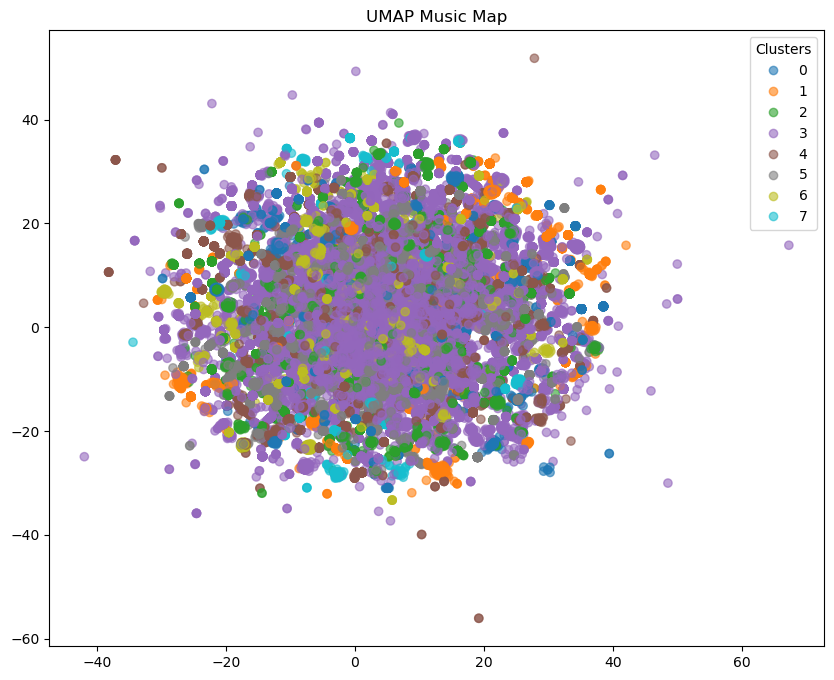

In [8]:
plt.figure(figsize=(10, 8))

scatter = plt.scatter(
    X_umap[:, 0],
    X_umap[:, 1],
    c=model_df["cluster"],
    cmap="tab10",
    alpha=0.6
)

plt.legend(*scatter.legend_elements(), title="Clusters")
plt.title("UMAP Music Map")
plt.show()

## 5. Cluster inspection

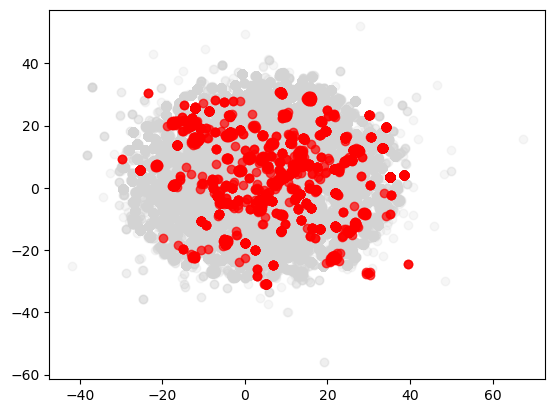

In [9]:
mask = model_df["cluster"] == 0

plt.scatter(X_umap[:,0], X_umap[:,1], color="lightgray", alpha=0.2)
plt.scatter(X_umap[mask,0], X_umap[mask,1], color="red", alpha=0.7)
plt.show()

## 6. Initial cluster interpretation

The initial K-Means clusters were inspected using representative artists and tag distributions to assess semantic coherence.

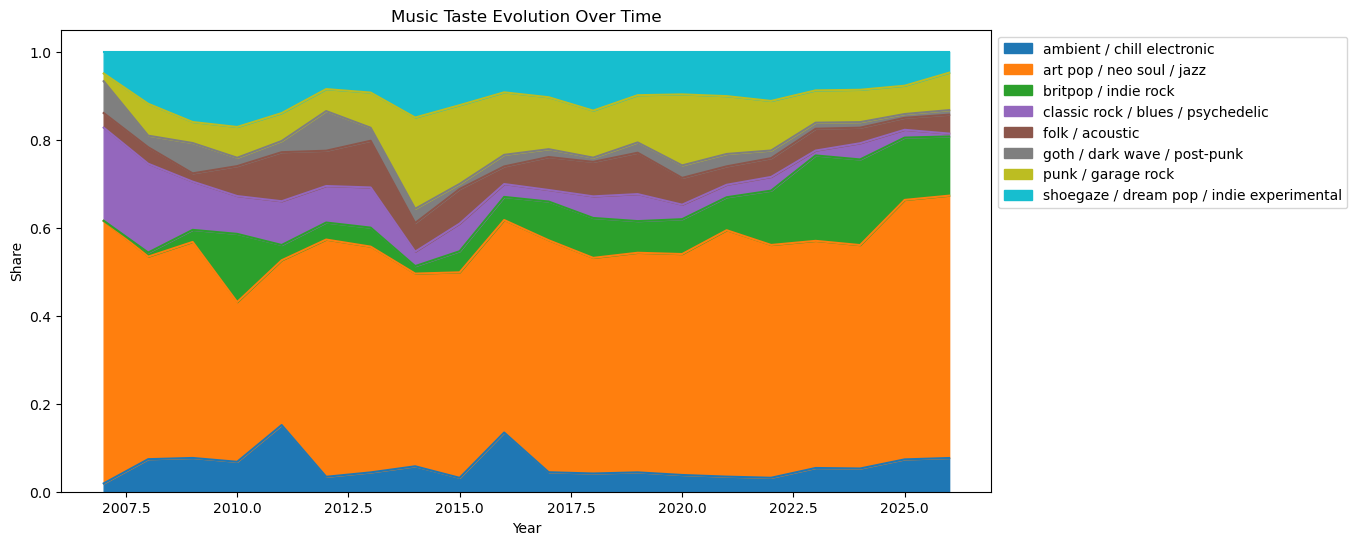

In [10]:
# Evolution of music taste over time

df = (
    model_df.groupby(["year_file", "cluster_name"])
    .size()
    .unstack(fill_value=0)
)

df_pct = df.div(df.sum(axis=1), axis=0)

df_pct.plot(kind="area", figsize=(12, 6), colormap="tab10")
plt.title("Music Taste Evolution Over Time")
plt.ylabel("Share")
plt.xlabel("Year")
plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
plt.show()

In [16]:
cluster_names_v2 = {
    0: "Americana / indie folk",
    1: "British alternative rock",
    2: "Ambient / trip-hop / downtempo",
    3: "Alternative rock mainstream",
    4: "Neoclassical / soundtrack",
    5: "Art indie / dream pop",
    6: "Soul / R&B / funk",
    7: "Post-punk / goth / new wave"
}

model_df["cluster_name_v2"] = model_df["cluster"].map(cluster_names_v2)

In [17]:
for cluster in model_df["cluster_name_v2"].unique():
    print("\n")
    print(cluster)

    print(
        model_df[
            model_df["cluster_name_v2"] == cluster
        ]["artist_clean"]
        .value_counts()
        .head(10)
    )



British alternative rock
artist_clean
radiohead         197
placebo           165
myslovitz         156
suede             143
blur              126
coldplay          117
snow patrol       112
arctic monkeys    111
muse              111
oasis             103
Name: count, dtype: int64


Alternative rock mainstream
artist_clean
red hot chili peppers    207
david bowie              205
green day                166
the rolling stones       149
tlove                    148
the beatles              147
deftones                 145
incubus                  117
tori amos                115
james blake              114
Name: count, dtype: int64


Post-punk / goth / new wave
artist_clean
foo fighters             166
the smashing pumpkins    154
pearl jam                110
garbage                  110
nirvana                   77
hey                       61
the afghan whigs          57
alice in chains           54
pixies                    50
soundgarden               47
Name: count, dtype: in

In [18]:
cluster_names_v3 = {
    0: "Alternative & Britrock",
    1: "Rock Canon & Alternative Classics",
    2: "Grunge & 90s Alternative",
    3: "Dark Alternative & Post-Punk",
    4: "Ambient & Trip-Hop Electronic",
    5: "Art Rock & Indie Experimental",
    6: "Americana & Singer-Songwriter",
    7: "Dream Pop & Modern Indie"
}

model_df["cluster_name_v3"] = model_df["cluster"].map(cluster_names_v3)

In [19]:
for cluster in model_df["cluster_name_v3"].unique():
    print("\n")
    print(cluster)

    print(
        model_df[
            model_df["cluster_name_v3"] == cluster
        ]["artist_clean"]
        .value_counts()
        .head(10)
    )



Rock Canon & Alternative Classics
artist_clean
radiohead         197
placebo           165
myslovitz         156
suede             143
blur              126
coldplay          117
snow patrol       112
arctic monkeys    111
muse              111
oasis             103
Name: count, dtype: int64


Dark Alternative & Post-Punk
artist_clean
red hot chili peppers    207
david bowie              205
green day                166
the rolling stones       149
tlove                    148
the beatles              147
deftones                 145
incubus                  117
tori amos                115
james blake              114
Name: count, dtype: int64


Dream Pop & Modern Indie
artist_clean
foo fighters             166
the smashing pumpkins    154
pearl jam                110
garbage                  110
nirvana                   77
hey                       61
the afghan whigs          57
alice in chains           54
pixies                    50
soundgarden               47
Name: count, dt

In [20]:
model_df["cluster_name_v3"].value_counts()

cluster_name_v3
Dark Alternative & Post-Punk         37296
Ambient & Trip-Hop Electronic         7763
Grunge & 90s Alternative              7446
Art Rock & Indie Experimental         6797
Alternative & Britrock                4257
Americana & Singer-Songwriter         3976
Rock Canon & Alternative Classics     3581
Dream Pop & Modern Indie              1707
Name: count, dtype: int64

In [21]:
model_df.groupby("cluster_name_v3")["artist_clean"].nunique()

cluster_name_v3
Alternative & Britrock                433
Ambient & Trip-Hop Electronic         953
Americana & Singer-Songwriter         439
Art Rock & Indie Experimental         830
Dark Alternative & Post-Punk         9874
Dream Pop & Modern Indie              126
Grunge & 90s Alternative              884
Rock Canon & Alternative Classics     171
Name: artist_clean, dtype: int64

In [22]:
model_df.groupby("cluster_name_v3").size()

cluster_name_v3
Alternative & Britrock                4257
Ambient & Trip-Hop Electronic         7763
Americana & Singer-Songwriter         3976
Art Rock & Indie Experimental         6797
Dark Alternative & Post-Punk         37296
Dream Pop & Modern Indie              1707
Grunge & 90s Alternative              7446
Rock Canon & Alternative Classics     3581
dtype: int64

In [23]:
(
    model_df["cluster_name_v3"]
    .value_counts(normalize=True)
    .mul(100)
    .round(1)
)

cluster_name_v3
Dark Alternative & Post-Punk         51.2
Ambient & Trip-Hop Electronic        10.7
Grunge & 90s Alternative             10.2
Art Rock & Indie Experimental         9.3
Alternative & Britrock                5.8
Americana & Singer-Songwriter         5.5
Rock Canon & Alternative Classics     4.9
Dream Pop & Modern Indie              2.3
Name: proportion, dtype: float64

In [24]:
model_df.groupby("cluster_name_v3")["tags_filtered"].count()

cluster_name_v3
Alternative & Britrock                4257
Ambient & Trip-Hop Electronic         7763
Americana & Singer-Songwriter         3976
Art Rock & Indie Experimental         6797
Dark Alternative & Post-Punk         37296
Dream Pop & Modern Indie              1707
Grunge & 90s Alternative              7446
Rock Canon & Alternative Classics     3581
Name: tags_filtered, dtype: int64

## 7. Macro-cluster consolidation

Because several initial clusters overlapped stylistically, they were merged into four broader categories used in the longitudinal analysis.

In [26]:
macro_map = {
    "Dark Alternative & Post-Punk": "Alternative Core",

    "Rock Canon & Alternative Classics": "Rock & Britrock",
    "Alternative & Britrock": "Rock & Britrock",
    "Grunge & 90s Alternative": "Rock & Britrock",

    "Ambient & Trip-Hop Electronic": "Electronic & Ambient",
    "Art Rock & Indie Experimental": "Electronic & Ambient",
    "Dream Pop & Modern Indie": "Electronic & Ambient",

    "Americana & Singer-Songwriter": "Singer-Songwriter"
}

model_df["macro_cluster_v2"] = model_df["cluster_name_v3"].map(macro_map)

In [27]:
model_df["macro_cluster_v2"].value_counts(normalize=True)

macro_cluster_v2
Alternative Core        0.512146
Electronic & Ambient    0.223377
Rock & Britrock         0.209879
Singer-Songwriter       0.054598
Name: proportion, dtype: float64

In [28]:
# Years 2007 and 2026 are incomplete, so we will exclude them from the analysis
analysis_df = model_df[
    (model_df["year_file"] >= 2008)
    & (model_df["year_file"] <= 2025)
]

## 8. Final macro-clusters

The initial K-Means solution produced several overlapping musical categories. After manual inspection, the clusters were consolidated into four broader macro-clusters that better represent long-term listening patterns and are used throughout the final longitudinal analysis. The following visualization illustrates how the relative share of these macro-clusters changed over time.

In [29]:
macro_year = (
    model_df
    .groupby(["year_file", "macro_cluster_v2"])
    .size()
    .unstack(fill_value=0)
)

macro_pct = (
    pd.crosstab(
        analysis_df["year_file"],
        analysis_df["macro_cluster_v2"],
        normalize="index"
    )
)

macro_pct.head()

macro_cluster_v2,Alternative Core,Electronic & Ambient,Rock & Britrock,Singer-Songwriter
year_file,,,,
2008,0.460341,0.108029,0.357664,0.073966
2009,0.490995,0.144088,0.288175,0.076742
2010,0.363000,0.244000,0.325000,0.068000
2011,0.374499,0.123498,0.350467,0.151535
2012,0.539151,0.178774,0.248113,0.033962


In [108]:
macro_pct.tail()

macro_cluster_v2,Alternative Core,Electronic & Ambient,Rock & Britrock,Singer-Songwriter
year_file,,,,
2021,0.560029,0.234519,0.171150,0.034302
2022,0.529092,0.253566,0.185623,0.031719
2023,0.516210,0.281322,0.148504,0.053964
2024,0.507788,0.280740,0.158695,0.052776
2025,0.589711,0.214555,0.122244,0.073490


In [30]:
CLUSTER_COLORS = {
    "Alternative Core": "#4E79A7",      
    "Electronic & Ambient": "#F28E2B",            
    "Rock & Britrock": "#59A14F",                  
    "Singer-Songwriter": "#E15759"             
}

<Figure size 1200x600 with 0 Axes>

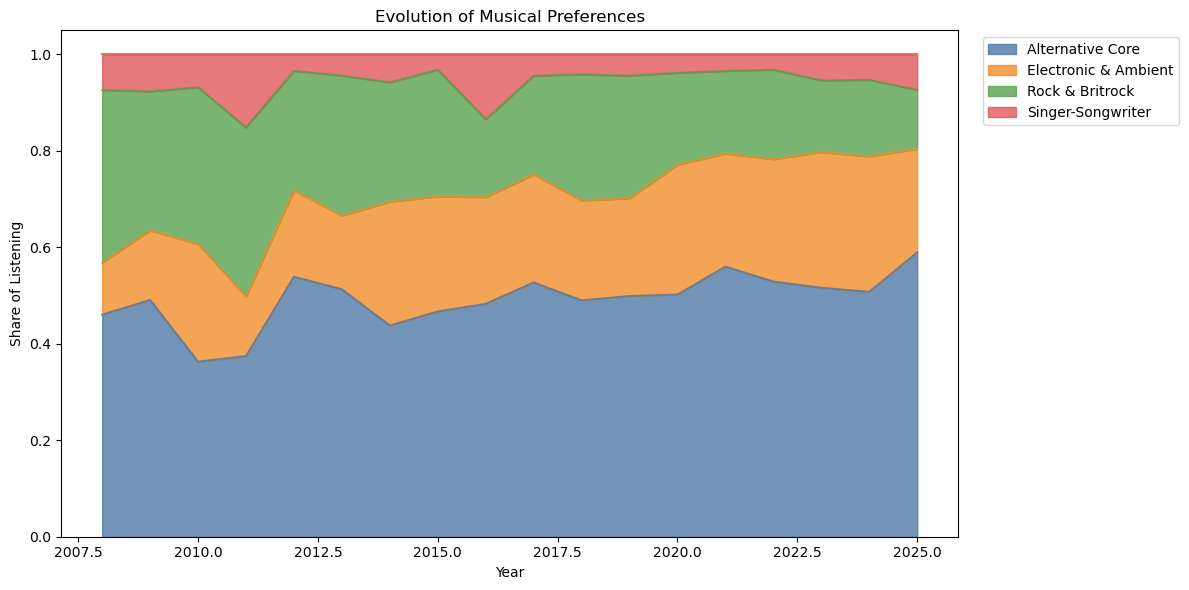

In [31]:
colors = [CLUSTER_COLORS[c] for c in macro_pct.columns]

plt.figure(figsize=(12,6))

macro_pct.plot.area(
    figsize=(12,6),
    alpha=0.8,
    color=colors
)

plt.title("Evolution of Musical Preferences")
plt.ylabel("Share of Listening")
plt.xlabel("Year")

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

## 9. Export processed dataset

In [68]:
# Save current dfs

model_df.to_csv(
    "../data/processed/final/music_taste_clusters_final.csv",
    index=False
)

import pickle

#model_df.to_pickle("../data/processed/final/music_taste_clusters_final.pkl")

with open(
    "../data/processed/final/music_taste_clusters_final.pkl",
    "wb"
) as f:
    pickle.dump(model_df, f)

In [ ]:
# how to load pickle, if needed:
with open(
    "../data/processed/music_taste_clusters_final.pkl",
    "rb"
) as f:
    model_df = pickle.load(f)

In [12]:
import pickle

with open("tfidf_vectorizer.pkl", "wb") as f:
    pickle.dump(vectorizer, f)